# RideWise --- Customer Segmentation 

- purpose : Group all the riders into different behavioral clusters, we tailor retention strategies 

In [3]:
## Setup & import libraries

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)


# import our algorithm libraries 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



# define the data paths
DATA_PROCESSED = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

features = pd.read_csv(os.path.join(DATA_PROCESSED, "features.csv"))


## Step 1- Select Clustering Features

- We need to define the features we'd use for segmentation
   - 1 - RFM features
   - 2 - Trips behvaior
   - 3 - Session engagement features
   - 4 - Temporal features

In [4]:
features.head()

,user_id,churned,days_since_last_trip,days_since_last_session,trips_last_7d,trips_last_30d,trips_last_60d,trips_last_90d,monetary_total,monetary_avg,...,avg_pages_visited,session_conversation_rate,engagement_score,account_age_days,activity_trend_30d,unique_active_days,was_referred,avg_rating_given,loyalty_encoded,city_encoded
0,R00000,0,25,0.0,0,1,1,3,414.13,16.57,...,3.00,0.25,276.00,93,0.50,25,1,5.0,0,0
1,R00001,1,5,0.0,1,2,3,3,195.69,13.98,...,2.67,0.00,466.37,230,0.67,13,0,4.7,0,0
2,R00002,1,14,0.0,0,1,4,5,482.94,20.12,...,3.00,0.00,573.00,232,0.50,22,0,4.2,0,1
3,R00004,0,12,0.0,0,2,2,5,391.15,24.45,...,2.50,0.00,42.50,250,0.67,16,1,3.9,1,1
4,R00005,0,2,0.0,1,2,2,4,300.63,15.82,...,1.67,0.17,50.65,657,0.67,19,0,5.0,0,1


In [5]:
CLUSTER_COLS = [

    # RFM Score Features
    "rfm_recency_score", "rfm_frequency_score", "rfm_monetary_score",

    # Trips behaviour
    "avg_fare", "avg_surge", "tip_rate", "peak_hour_rate", "weekend_ratio",

    # Sessioon engagement
    "session_last_30d", "avg_time_on_app", "session_conversation_rate", "engagement_score",

    # Temporal features
    "account_age_days", "activity_trend_30d",
]

# K-Means clustering cant handle missing values
seg_df = features[["user_id", "churned" ] + CLUSTER_COLS].dropna().copy()
print(f"Riders for segentation: {len(seg_df)}")

Riders for segentation: 9204


## Step 2 - SCALING & The ELbow Test

## why are we scaling 

#### example without scaling
 - RIDER A : account_age_days = 500, rfm_recency_score = 5
 - RIDER B : account_age_days = 100, rfm_recency_score = 1

#### The problem (DISTANCE CALCULATIONS)
 - different in account age = 500-100 = 400
 - different in recency_score = 5 - 1 = 4
 - Total distance = sqrt(400^2 + 4^2) = 400

###### the problem this huge 400-days difference dominates, recency score 1 vs 4 doesnt really matter


###### Solution scaling
  -  convert each feature of that riders to mean=0 and std = 1
  - both features from these rider can contribute equally to distance calculation

###### Example with Standard scaling
 - RIDER A : account_age = 1.2, rfm_recency = 1.5
 - RIDER B : account_age = -0.8, rfm_recency = -1.2

##### DISTANCE CALCULATION
- sqrt(2^2 + 2.7^2) = 3.4        (huges)





In [6]:
scalar = StandardScaler()
X = scalar.fit_transform(seg_df[CLUSTER_COLS])

#### Step 3 - Elbow + Silhouttee Test: Finding the right number of clustering

- How many customers group should we create
- k= 2
- k = 20
- 4-6

##### Inertia (sum of squares)
 - measure how tightly packed each group/cluster is
 - Lower the cluster the better (more space)
 - sum of squared distance from each point to its cluster center

In [7]:
# KMEANS CLUSTERING
inertias = []
silhouettes = [] 
K_RANGE = range(2,9)

# K - Number of clusters
# Means - Algorithm uses mean (average) of data point to find clusters
#n_init - run algorithm 10 times with different random state (42), picks the best result 
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=3000, random_state=42))

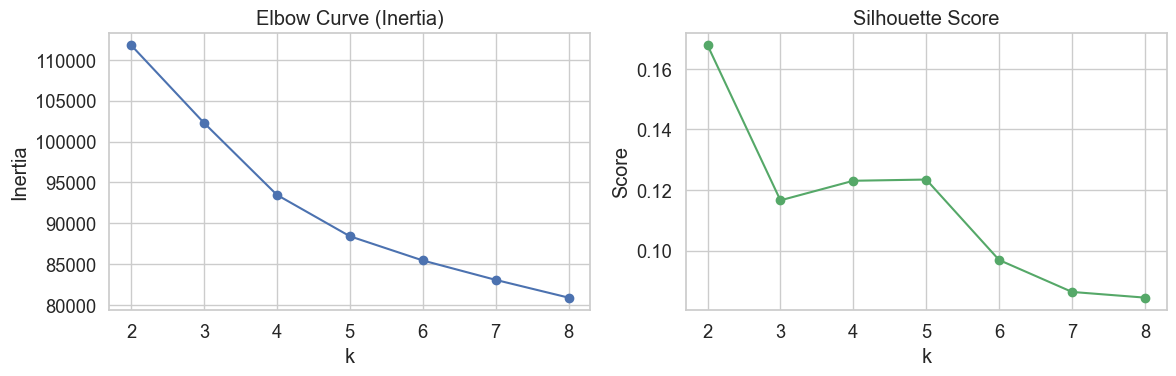

In [8]:
# Silhoutee Score
# Helps us to measure how well-seperated the cluster are 
# Range : -1 ------- 1
# closer 1 === better (cluster are distinct, no overlap)
# closer 0 ==== cluster overlapp


# Examples : For each rider 
# a -  averagef distance to others in same cluster (should be small)
# b = average distance to other in other cluter (should be large)


#silhouettes = (b-a)/ max(a, b)
# siloutee score = 0.7 Great clsuter are well seperated
 # silhoutee = 0.3 .... some might overlap
# siloutee is 0.1 clusters are poor


fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(list(K_RANGE), inertias, "bo-")
axes[0].set(title="Elbow Curve (Inertia)", xlabel="k", ylabel="Inertia")

axes[1].plot (list(K_RANGE), silhouettes, "go-")
axes[1].set(title="Silhouette Score", xlabel="k", ylabel="Score")

plt.tight_layout()
plt.show()

In [12]:
# 1 - ELBOW you look out for the sharp drop

# k = 2 ---- k = 3  inertia = 110k --- 102k  = 8k
# k = 3 --- k = 4  inertia = 102k - 93  still worth it 
# k = 4 --- k = 5  inertia = 93k - 88k  flattening 




# 2 - SILHOUTEE
# k = 2 silhoutee = 0.165  ------ useless 
# k = 3  "" = 0.117

# k = 4 = 0.123
# k = 5 = 0.122 ----- k = 4 or 5

# k = 6 = 0.097
# k = 7 = 0.083

# k = 8  = 0.080  ----- too many


# WHY ARE WE CHOOSING K = 4

# Elbow chart 
# inertia drops sharply untill k = 4
# After k = 4 , diminishing return (line flatten)


# SILHOUTEE CHART
# k = 4 had a descent seperation


#### Step 4 - Finding K

In [ ]:
K_FINAL = 4 
Kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
seg_df["cluster"] = Kmeans.fit_predict(X)

final_sil = silhouette_score(X, seg_df["cluster"], sample_size=3000, random_state=42)
print(f"k={K_FINAL} | Inertia:{Kmeans.inertia_:,.0f} | silhouette: {final_sil:.2f}")
print(seg_df["cluster"].value_counts().sort_index())

k=4 | Inertia:93,487 | silhouette: 0.12
cluster
0    3327
1    1766
2    3523
3     588
Name: count, dtype: int64


#### Step 5 - Cluster Profiling

- we've grouped rider into 4 clusters, but we dont know what makes each cluster unique.....
- show the average behavior of each cluster

In [ ]:
profile_cols = [
    "rfm_recency_score", "rfm_frequency_score", "rfm_monetary_score",
    "avg_fare", "session_last_30d", "engagement_score", "activity_trend_30d"
]

profile = seg_df.groupby("cluster")[profile_cols].mean().round(2)
print(profile.T.to_string())

cluster                   0       1       2        3
rfm_recency_score      3.52    1.01    3.48     3.20
rfm_frequency_score    3.63    1.00    3.36     3.29
rfm_monetary_score     4.10    2.62    2.14     3.09
avg_fare              16.32   15.39   14.52    15.45
session_last_30d       5.07    5.09    4.94     4.61
engagement_score     200.69  225.48  204.87  1152.91
activity_trend_30d     0.65    0.00    0.62     0.58


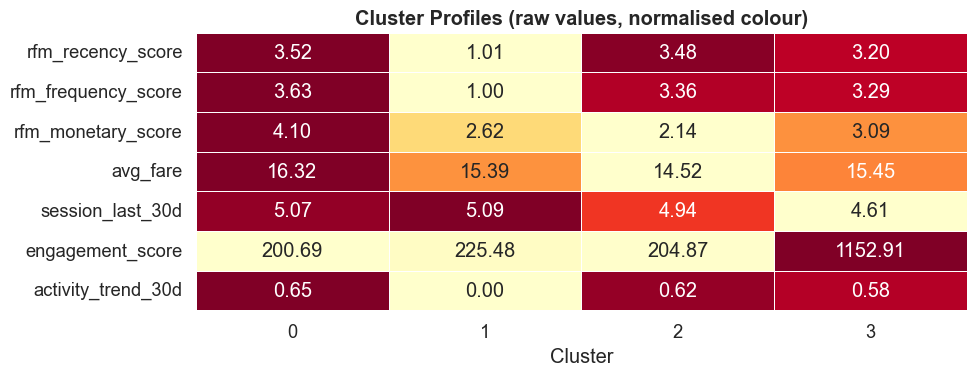

In [16]:
#cluster 0 = Hig RFM score --- champions
# clutser 1 = Low RFM score ---- Dormant

# Heat Map Visualization 
# normalization of profile converts all the average in our profile to 0-1


profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10, 4))

sns.heatmap(
    profile_norm.T, annot=profile.T, fmt=".2f", cmap="YlOrRd", linewidths=0.5, ax=ax, cbar=False
)

ax.set_title("Cluster Profiles (raw values, normalised colour)", fontweight="bold")
ax.set_xlabel("Cluster")
plt.tight_layout()
plt.show()

#### Step 6 - Assign Busines labels

In [ ]:
rfm_mean = seg_df.groupby("cluster")[[
    "rfm_recency_score", "rfm_frequency_score", "rfm_monetary_score"
]].mean().mean(axis=1)

rank = rfm_mean.rank(ascending=False).astype(int)


SEGMENT_LABELS = {}
names = ["Champions", "Loyal Riders", "At-Risk", "Dormant"]

for cluster_id , r in rank.items():
    SEGMENT_LABELS[cluster_id] = names[r - 1]

seg_df["segment"] = seg_df["cluster"].map(SEGMENT_LABELS)
print(seg_df["segment"].value_counts())

segment
At-Risk         3523
Champions       3327
Dormant         1766
Loyal Riders     588
Name: count, dtype: int64
